Dataset shape: (1000000, 33)

Feature types:
 posting_date                      object
internship_title                  object
employment_type                   object
work_mode                         object
industry                          object
location                          object
company_name                      object
company_size                      object
company_age                      float64
linkedin_presence                  int64
website_available                  int64
domain_age_months                  int64
verification_status                int64
stipend                          float64
unrealistic_salary_flag            int64
payment_required                   int64
registration_fee                   int64
job_description_length             int64
grammatical_errors                 int64
vague_description_score            int64
urgency_score                      int64
keyword_spam_score                 int64
fake_certificate_offer             int64
recruiter_e

C:\Users\PC\AppData\Local\Temp\ipykernel_18012\3466794897.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fake_posting', data=df, palette="Set2")


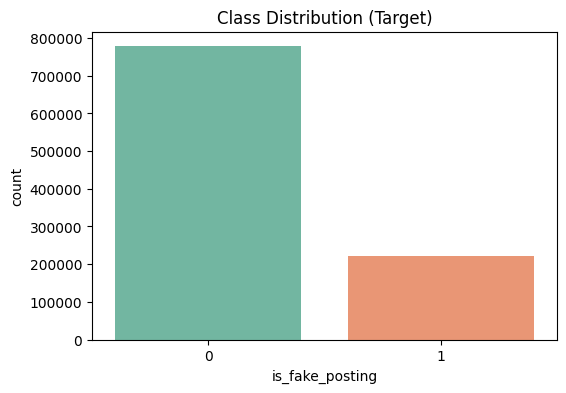

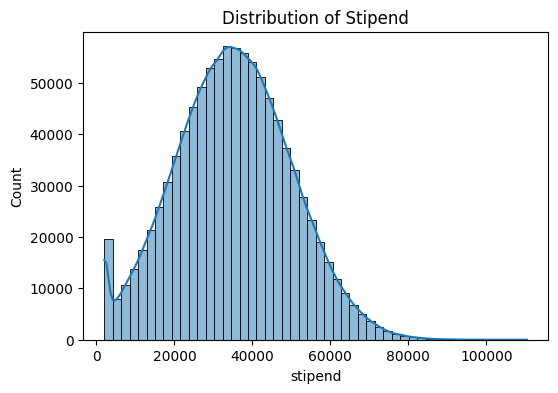

Target Variable : is_fake_posting
0 = Genuine
1 = Fake


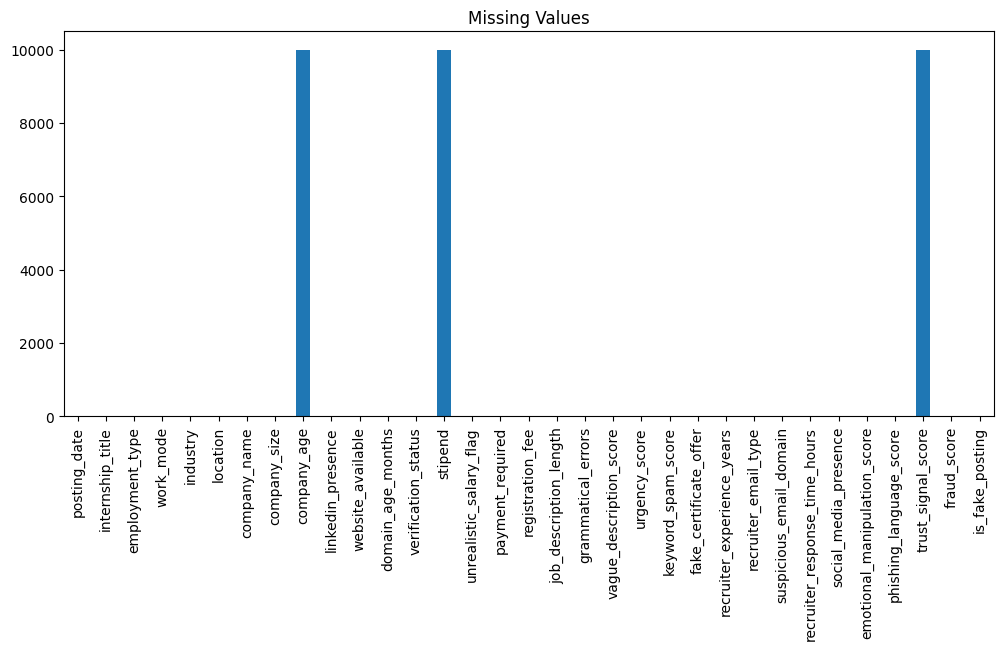

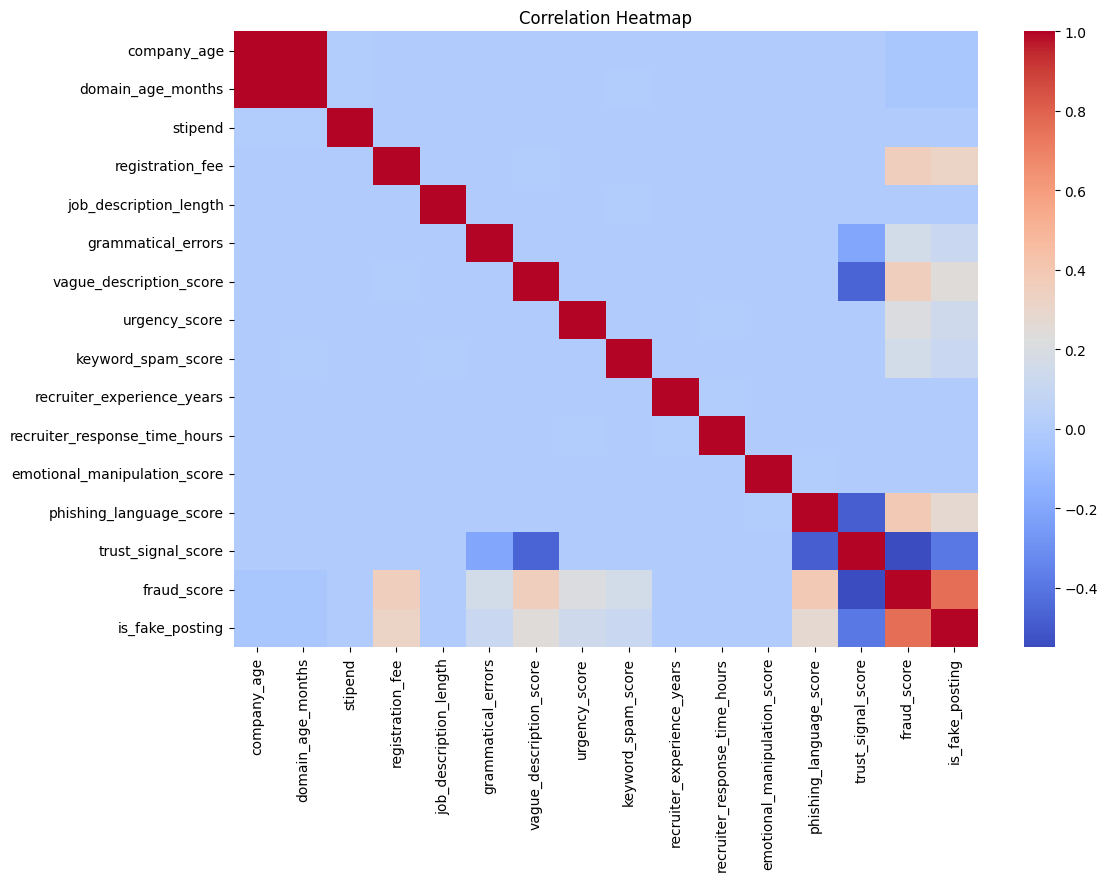

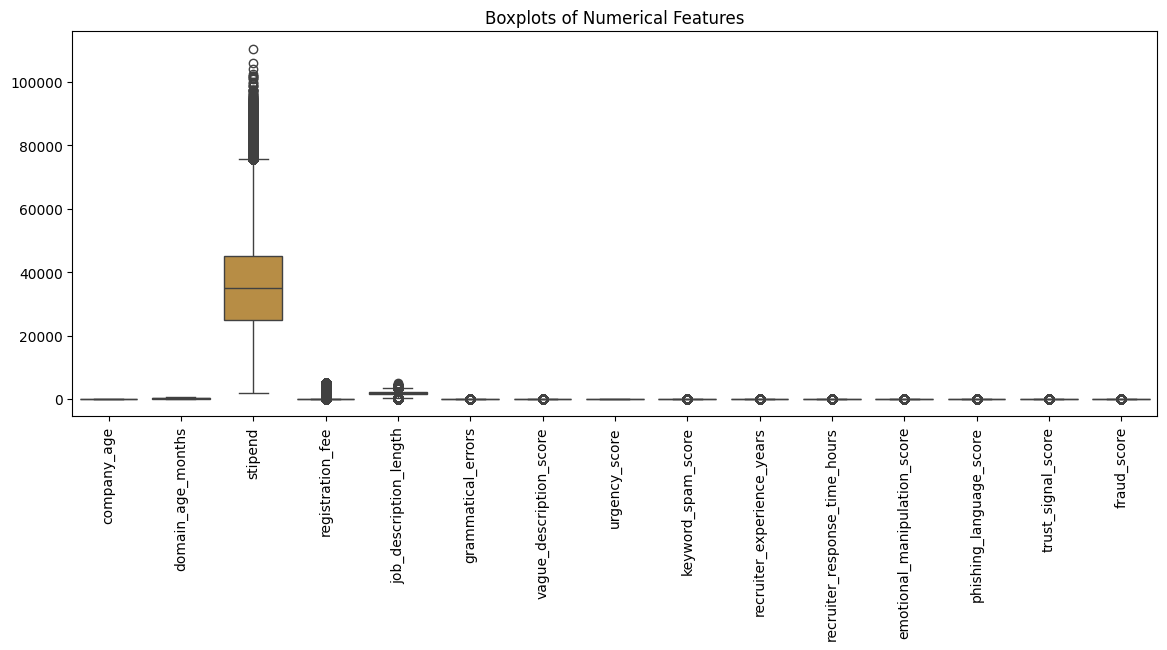

C:\Users\PC\AppData\Local\Temp\ipykernel_18012\3466794897.py:172: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



Imbalance ratio (Fake/Genuine): 0.29

StandardScaler was used because:
• Logistic Regression performs better on standardized features.
• Numerical variables have different ranges.
• Standardization improves convergence while not affecting tree-based models.


Final dataset shape: (1000000, 66)
Final features: ['location', 'company_name', 'company_size', 'company_age', 'linkedin_presence', 'website_available', 'domain_age_months', 'verification_status', 'stipend', 'unrealistic_salary_flag', 'payment_required', 'registration_fee', 'job_description_length', 'grammatical_errors', 'vague_description_score', 'urgency_score', 'keyword_spam_score', 'fake_certificate_offer', 'recruiter_experience_years', 'suspicious_email_domain', 'recruiter_response_time_hours', 'social_media_presence', 'emotional_manipulation_score', 'phishing_language_score', 'trust_signal_score', 'fraud_score', 'is_fake_posting', 'posting_year', 'posting_month', 'posting_day', 'posting_weekday', 'ai', 'analyst', 'backend',

In [3]:
# ============================================
# Fake Internship Posting Detection - EDA + Preprocessing
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv("fake_internship_detection_dataset.csv")

# ============================================
# Part 1: Exploratory Data Analysis (EDA)
# ============================================

# 1. Dataset dimensions
print("Dataset shape:", df.shape)

# 2. Feature names and data types
print("\nFeature types:\n", df.dtypes)

# 3. Statistical summary for numerical features
print("\nNumerical summary:\n", df.describe())

# 4. Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"MissingCount": missing, "MissingPct": missing_pct})
print("\nMissing values:\n", missing_summary)

# 5. Duplicate records
duplicates = df.duplicated().sum()
print(f"\nDuplicate records: {duplicates} ({duplicates/len(df)*100:.2f}%)")

# 6. Class distribution
class_dist = df['is_fake_posting'].value_counts()
class_prop = df['is_fake_posting'].value_counts(normalize=True)
print("\nClass distribution:\n", pd.DataFrame({"Count": class_dist, "Proportion": class_prop}))

# 7. Visualizations
plt.figure(figsize=(6,4))
sns.countplot(x='is_fake_posting', data=df, palette="Set2")
plt.title("Class Distribution (Target)")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['stipend'], bins=50, kde=True)
plt.title("Distribution of Stipend")
plt.show()

# -------------------------------
# Additional Visualizations
# -------------------------------
print("Target Variable : is_fake_posting")
print("0 = Genuine")
print("1 = Fake")

# Missing values bar plot
missing_summary['MissingCount'].plot(kind='bar', figsize=(12,5))
plt.title("Missing Values")
plt.show()

# Correlation heatmap
num_features = [
    'company_age','domain_age_months','stipend','registration_fee',
    'job_description_length','grammatical_errors','vague_description_score',
    'urgency_score','keyword_spam_score','recruiter_experience_years',
    'recruiter_response_time_hours','emotional_manipulation_score',
    'phishing_language_score','trust_signal_score','fraud_score'
]

plt.figure(figsize=(12,8))
sns.heatmap(df[num_features+['is_fake_posting']].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Boxplots for numerical features
plt.figure(figsize=(14,5))
sns.boxplot(data=df[num_features])
plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Features")
plt.show()

# ============================================
# Part 2: Data Preprocessing
# ============================================

# -------------------------------
# Date Feature
# -------------------------------
df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')
df['posting_year'] = df['posting_date'].dt.year
df['posting_month'] = df['posting_date'].dt.month
df['posting_day'] = df['posting_date'].dt.day
df['posting_weekday'] = df['posting_date'].dt.weekday
df.drop(columns=['posting_date'], inplace=True)

# -------------------------------
# Text Feature (TF-IDF)
# -------------------------------
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['internship_title'].fillna(""))

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
df = pd.concat([df.drop(columns=['internship_title']), tfidf_df], axis=1)

# -------------------------------
# Nominal Features (One-Hot Encoding)
# -------------------------------
nominal_features = ['employment_type', 'work_mode', 'recruiter_email_type']
industry_cardinality = df['industry'].nunique()

if industry_cardinality < 50:  # manageable cardinality
    nominal_features.append('industry')
else:
    # Frequency encoding for industry
    industry_freq = df['industry'].value_counts(normalize=True)
    df['industry'] = df['industry'].map(industry_freq)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(df[nominal_features].fillna("Unknown"))
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(nominal_features))

df = pd.concat([df.drop(columns=nominal_features), encoded_df], axis=1)

# -------------------------------
# High-Cardinality Features (Frequency Encoding)
# -------------------------------
for col in ['location', 'company_name']:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq)

# -------------------------------
# Ordinal Feature
# -------------------------------
size_mapping = {"Small": 1, "Medium": 2, "Large": 3}
df['company_size'] = df['company_size'].map(size_mapping)

# -------------------------------
# Binary Features
# -------------------------------
binary_features = [
    'linkedin_presence','website_available','verification_status',
    'unrealistic_salary_flag','payment_required','fake_certificate_offer',
    'suspicious_email_domain','social_media_presence'
]

for col in binary_features:
    df[col] = df[col].map({"Yes":1, "No":0})

# -------------------------------
# Outlier Detection & Treatment
# -------------------------------
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

# -------------------------------
# Missing Value Imputation
# -------------------------------
for col in num_features:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# -------------------------------
# Remove Duplicates
# -------------------------------
df.drop_duplicates(inplace=True)

# -------------------------------
# Class Imbalance Analysis
# -------------------------------
imbalance_ratio = class_dist[1] / class_dist[0]
print(f"\nImbalance ratio (Fake/Genuine): {imbalance_ratio:.2f}")

# -------------------------------
# Feature Scaling
# -------------------------------
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

print("""
StandardScaler was used because:
• Logistic Regression performs better on standardized features.
• Numerical variables have different ranges.
• Standardization improves convergence while not affecting tree-based models.
""")

# ============================================
# Final Dataset Ready for ML
# ============================================
print("\nFinal dataset shape:", df.shape)
print("Final features:", df.columns.tolist()[:50], "...")  # show first 50 features
print(df.head())
